# Deep Q Network
<b> Temporal Difference (TD) Learning </b> find more efficient way to calculate expected return in respect to Monte Carlo method that was usuing all the samples. TD is based on bootsrapping approach, to estimate the value based on the other estimates. It uses exponentially smoothed mean (in case of data sample comes from non-stationary distribuition), which really leads to gradient descent (calcualting error as squre difference between target and prediction). 


<b> Q-learning </b> focuses on updating Q(s, a) that recursively also depends on V. It is off-policy algorithm, because it uses the same update rule. We use the same value regardless of which action we choose. 
Q - update:

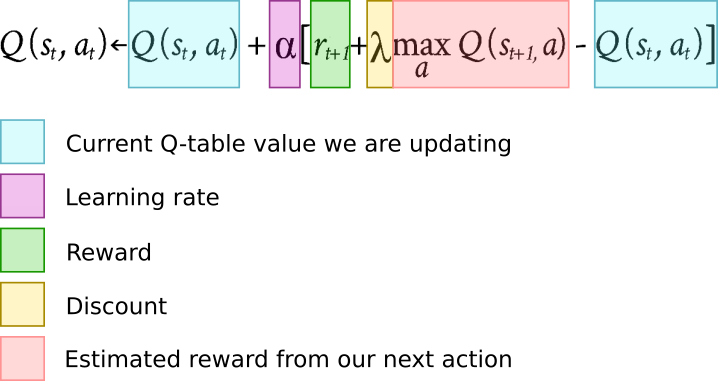



We want to store recieved Q values in q-table, however this is not efficient and is problematic for continious action spaces. The answer is parameterized value function e.g. with linear regression or neural network. 
In Q-learning the target is not given as in case of supervised learning, it depends on the prediction. So gradient descent is not true gradient desceent (it's "semi-gradient"). So the target doesn't say true Q value, just an estimate. 

In <b> Deep Q-learning </b> every transition (s, a, r, s', done) is saved in replay buffer / memory. So later on we can build prediction/target on that. It allows to train the model in batch size manner. For the gradient descent we don't take just the most recent transactiion, but sample for a batch from the replay buffer, calculate the target (based on the target network) and then perform gradient descent on sampled batch. There are in fact 2 networks: main Q networka and target Q network (stable copy of the main network copied every X steps during the simulation).
Deep Q-learning can be only used for discere action spaces, because each output node represents an action.

Paper: https://arxiv.org/abs/1312.5602

In [1]:
# !pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

In [2]:
import os
import pprint
import random
import warnings
import numpy as np

from gym import Env
from gym.spaces import Discrete, Box
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

import gym
from stable_baselines3 import PPO
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecCheckNan
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env

DQN_path = os.path.join('Training', 'Saved Models', 'DQN_model')
save_path = os.path.join('Training', 'Saved Models')
log_path = os.path.join('Training', 'Logs')

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'


warnings.filterwarnings("ignore")

Prepare the enviroment

In [3]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 1
VM_TYPE1 = 5
VM_TYPE2 = 3
VM_TYPE3 = 1
STEPS = 100
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          alpha = ALPHA,
          beta = BETA)

In [4]:
# PASSED THE TEST -> DO NOT REPEAT ANYMORE 
# check_env(env, warn=0, skip_render_check=1) 

Adding callbacks

In [5]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=190, verbose=1)
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

Train the model

In [6]:
model = DQN('MlpPolicy', env, verbose = 1, tensorboard_log=log_path)
model.learn(total_timesteps=20000, callback=eval_callback)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to Training\Logs\DQN_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -99      |
|    exploration_rate | 0.81     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 0        |
|    time_elapsed     | 1205     |
|    total_timesteps  | 400      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -99      |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 0        |
|    time_elapsed     | 2687     |
|    total_timesteps  | 800      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |


Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -99      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 24       |
|    fps              | 0        |
|    time_elapsed     | 8446     |
|    total_timesteps  | 2400     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -99      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 28       |
|    fps              | 0        |
|    time_elapsed     | 9869     |
|    total_timesteps  | 2800     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes       

Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.8    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 80       |
|    fps              | 0        |
|    time_elapsed     | 29170    |
|    total_timesteps  | 8000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.8    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 84       |
|    fps              | 0        |
|    time_elapsed     | 30489    |
|    total_timesteps  | 8400     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 164      |
|    fps              | 0        |
|    time_elapsed     | 67849    |
|    total_timesteps  | 16400    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 168      |
|    fps              | 0        |
|    time_elapsed     | 69246    |
|    total_timesteps  | 16800    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes       

In [7]:
model_path = os.path.join('Training', 'Saved Models', 'best_model')
model = DQN.load(model_path, env=env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Evaluate the policy

In [7]:
evaluate_policy(model, env, n_eval_episodes=10, render=True)

(-99.0, 0.0)

Test the model

In [8]:
# restart env
obs = env.reset()
done = False

culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []


while True:
    action, _states = model.predict(obs)
    obs, rewards, done, info = env.step(action)
    
    # save the resuls
    culumative_reward+=rewards
    step +=1
    value.append(culumative_reward)
    steps_lst.append(step)
    quality_of_service.append(info['Quality of Service'])
    utility_function.append(obs)
    cost_lst.append(info['Current cost'])
    no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
    queue_len.append(info['Queue len'])
    
    if done: 
        print('info', info)
        break

info {'Quality of Service': 0.5496, 'Current cost': 146.67, 'Queue len': 12, 'Timer': 6.595722675323486, 'VM type I': 15, 'VM type II': 4, 'VM type III': 0}


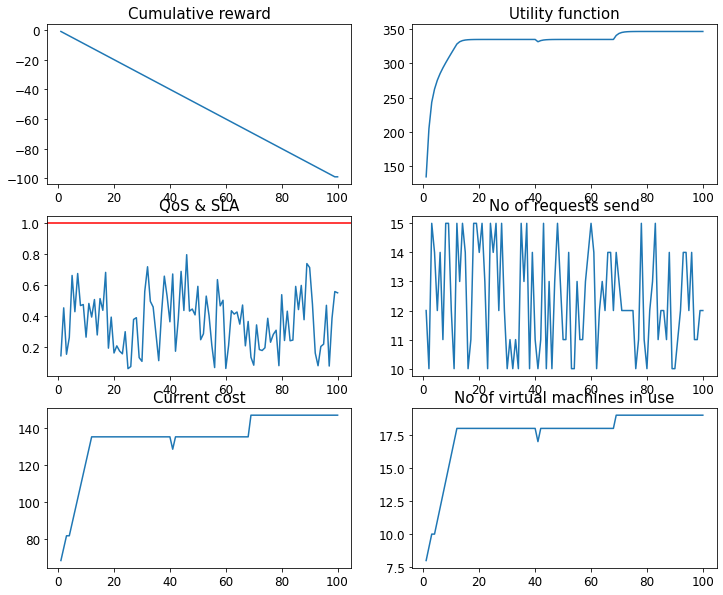

In [9]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)

In [11]:
# training_log_path = os.path.join(log_path, 'A2C_1')
# training_log_path